<h1>Diffusion on graphs</h1>

<h2>Heatmap at different t</h2>

In [43]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
import seaborn as sns

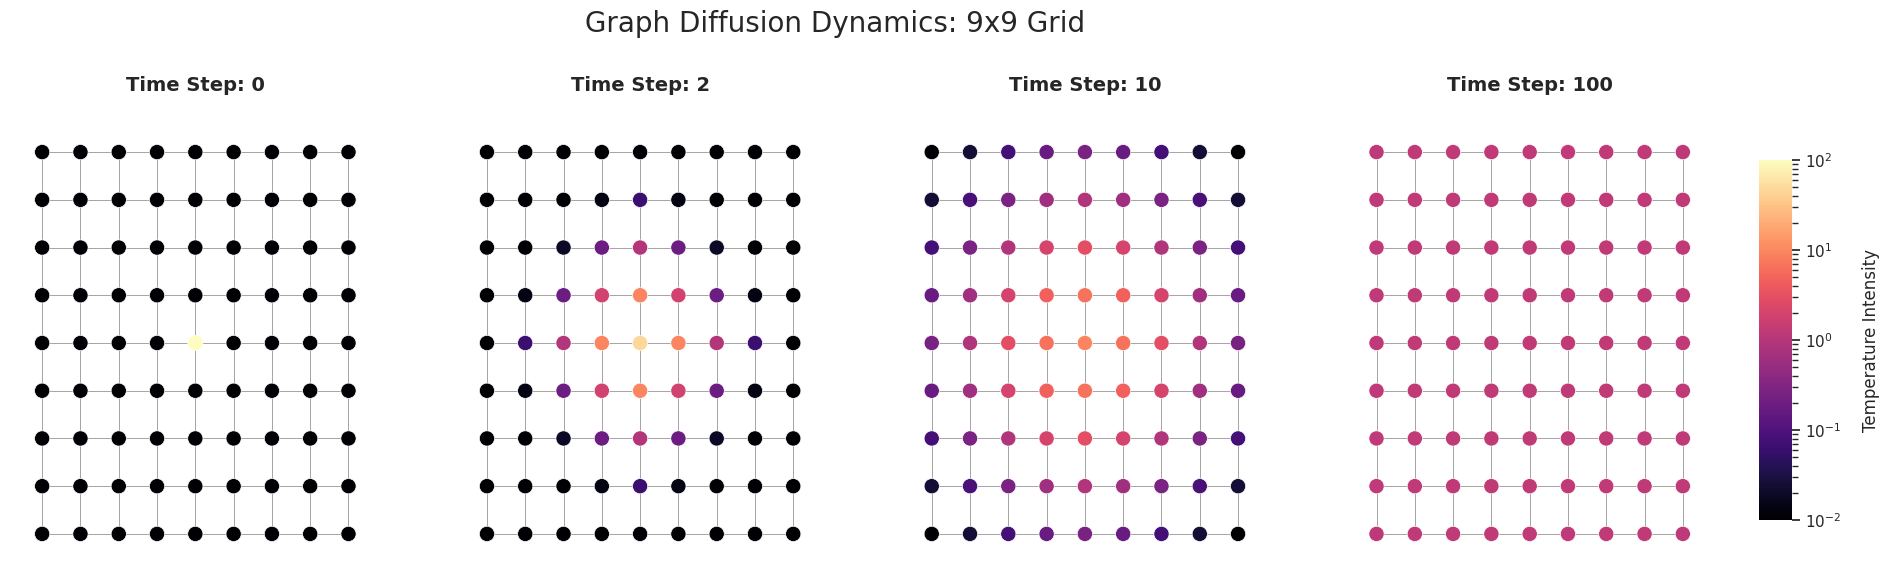

In [52]:
# Set Seaborn aesthetic style
sns.set_theme(style="white")

# Creating a grid 10x10 (using n_side=9 to match your index logic)
n_side = 9
G = nx.grid_2d_graph(n_side, n_side)
pos = {node: node for node in G.nodes()}

# Laplacian matrix calculation
L = nx.laplacian_matrix(G).toarray()

# Initial state
u0 = np.zeros(len(G.nodes()))
nodes_list = list(G.nodes())
center_idx = nodes_list.index((4, 4))
u0[center_idx] = 100.0  # High initial temperature

# Temporal evolution
times = [0, 2, 10, 100]
beta = 0.1

# Increase figure quality for vector output
fig, axes = plt.subplots(1, 4, figsize=(22, 6), facecolor="#FFFFFF") 

# Define logarithmic normalization
norm_log = LogNorm(vmin=1e-2, vmax=u0.max())
mapper = cm.ScalarMappable(norm=norm_log, cmap='magma')

for i, t in enumerate(times):
    u_t = expm(-beta * L * t) @ u0
    colors = mapper.to_rgba(u_t + 1e-3)
    
    ax = axes[i]
    ax.set_facecolor("#FFFFFF")
    
    # Plotting edges with a very subtle look (vector lines)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5, edge_color='black', width=0.5)
    
    # Plotting nodes with vector definition
    nx.draw_networkx_nodes(
        G, pos, 
        ax=ax, 
        node_size=120, 
        node_color=colors,
        edgecolors='white', 
        linewidths=0.5
    )
    
    ax.set_title(f"Time Step: {t}", fontsize=14, fontweight='bold', pad=15)
    ax.set_axis_off()

# Style the colorbar
mapper.set_array([])
cax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mapper, cax=cax)
cbar.outline.set_visible(False)
cbar.set_label('Temperature Intensity', fontsize=12, labelpad=15)

plt.suptitle(f"Graph Diffusion Dynamics: {n_side}x{n_side} Grid", 
             fontsize=20, y=1.05)

# Save as PDF (Vector format)
plt.savefig("diffusion_heatmap.pdf", format='pdf', bbox_inches='tight')

<h2>Modes in graph diffusion</h2>

First eigenvalues of L [-5.91384590e-15  2.67790359e-01  5.15484926e-01  6.60092081e-01
  7.99676512e-01  8.30816037e-01  8.96380642e-01  9.75063215e-01
  1.11533503e+00  1.20483568e+00]


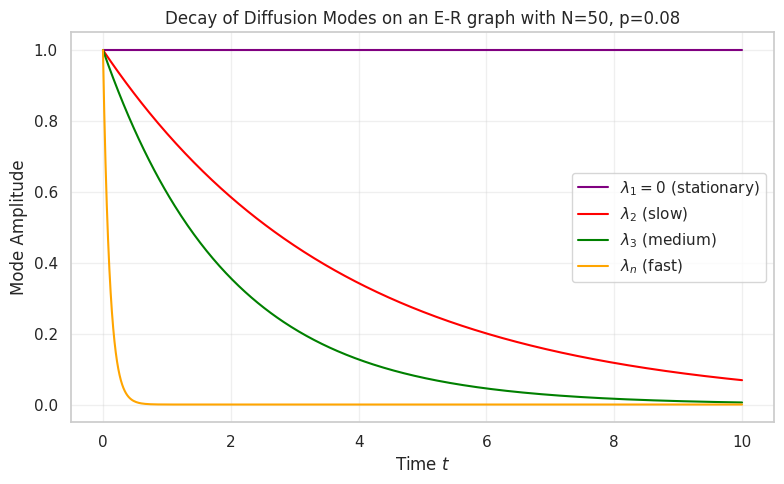

In [75]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Building a ER graph
N=50
G=nx.erdos_renyi_graph(N,p=0.08, seed=42)

#Laplacian matrix
L=nx.laplacian_matrix(G).toarray()

#Eigenvalues of L
eigvals= np.linalg.eigvalsh(L)
eigvals_sorted=np.sort(eigvals)

print("First eigenvalues of L", eigvals_sorted[:10])

#Choosing eigenvals to be plotted
lambda1 = eigvals_sorted[0]       
lambda2 = eigvals_sorted[1]
lambda3 = eigvals_sorted[2]
lambdan = eigvals_sorted[-1]

t_max=10
t=np.linspace(0,t_max,500)

# Modes amplitudes
mode1 = np.exp(-lambda1 * t)   
mode2 = np.exp(-lambda2 * t)
mode3 = np.exp(-lambda3 * t)
moden = np.exp(-lambdan * t)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

plt.plot(t, mode1, color="purple", label=r"$\lambda_1 = 0$ (stationary)")
plt.plot(t, mode2, color="red",    label=r"$\lambda_2$ (slow)")
plt.plot(t, mode3, color="green",  label=r"$\lambda_3$ (medium)")
plt.plot(t, moden, color="orange", label=r"$\lambda_n$ (fast)")

plt.xlabel("Time $t$")
plt.ylabel("Mode Amplitude")
plt.title("Decay of Diffusion Modes on an E-R graph with N=50, p=0.08")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("decay_modes.pdf", format="pdf", bbox_inches="tight")
plt.show()


<h2>Diffusion and cutsets (Cheeger)</h2>

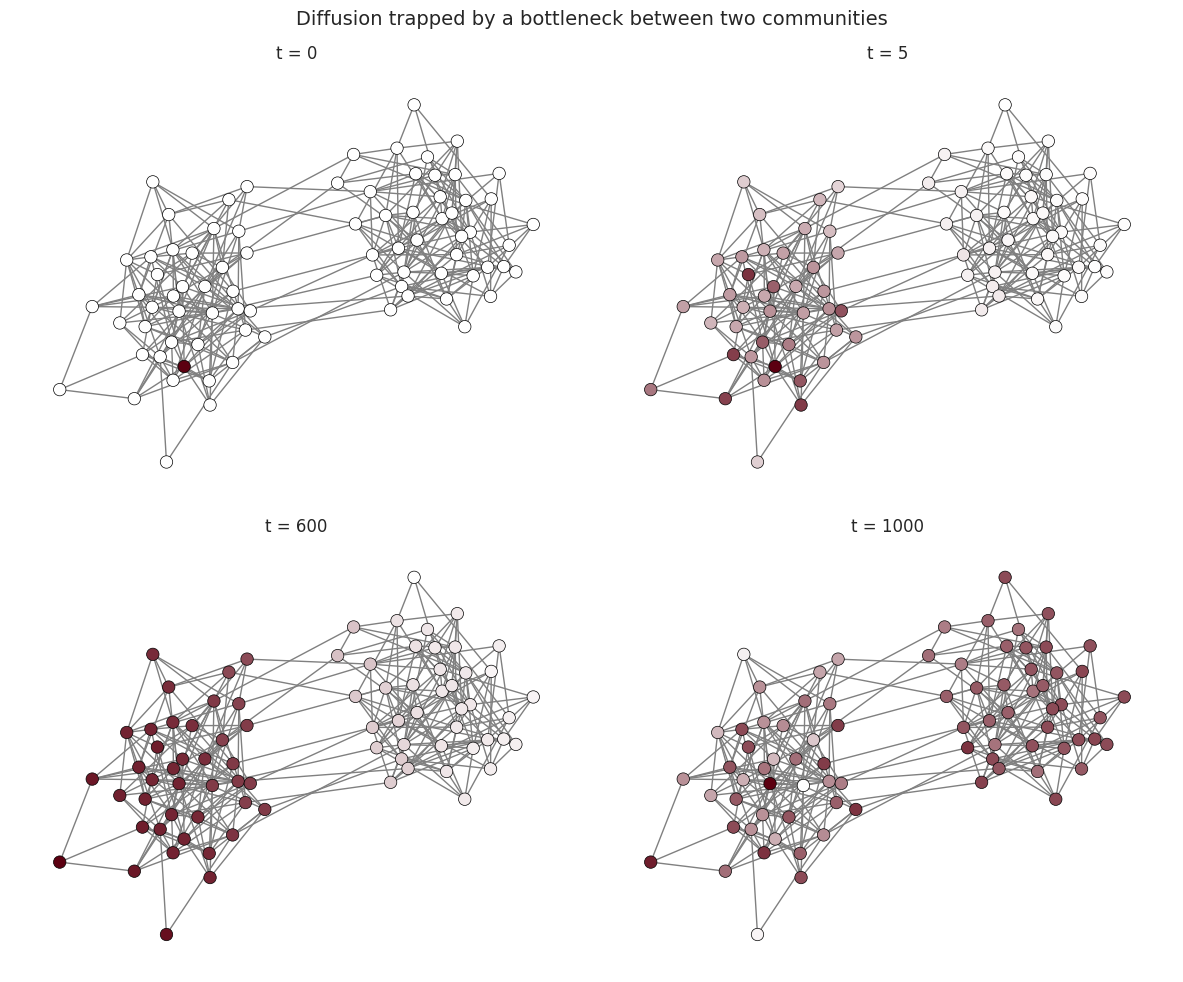

In [104]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Bordeaux colormap (white → bordeaux)
bordeaux = LinearSegmentedColormap.from_list(
    "bordeaux",
    ["#ffffff", "#5c0011"]
)

sns.set_theme(style="whitegrid")

# Two communities of 40 nodes
sizes = [40, 40]
p_in = 0.2
p_out = 0.005

probs = [
    [p_in,  p_out],
    [p_out, p_in ]
]

G = nx.stochastic_block_model(sizes, probs, seed=42)

# Laplacian
L = nx.laplacian_matrix(G).toarray()

# Eigenvectors and eigenvalues
eigvals, eigvecs = np.linalg.eigh(L)

# Diffusion
def diffuse(x0, t):
    coeffs = eigvecs.T @ x0
    alpha = 0.10
    xt = eigvecs @ (coeffs * np.exp(-alpha * eigvals * t))
    return xt

N = G.number_of_nodes()

# Initial signal
x0 = np.zeros(N)
x0[0] = 1.0

# Four time snapshots
times = [0, 5, 600, 1000]
snapshots = [diffuse(x0, t) for t in times]

# Layout
pos = nx.spring_layout(G, seed=1, k=0.3)

# ---- 2×2 FIGURE ----
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()  # flatten to iterate easily

for ax, t, x in zip(axes, times, snapshots):
    nx.draw(
        G, pos,
        node_color=x,
        cmap=bordeaux,
        node_size=80,
        edge_color="gray",
        edgecolors="black",
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(f"t = {t}", fontsize=12)
    ax.axis("off")

plt.suptitle("Diffusion trapped by a bottleneck between two communities", fontsize=14)
plt.tight_layout()
plt.savefig("diffusion_bottleneck_2x2.pdf", format="pdf", bbox_inches="tight")
plt.show()


